# ARTI 308 – Lab 5: Feature Engineering (Classification)
## Subscription Status Prediction using Customer Shopping Behavior Dataset

### Lab focus
This dataset is already clean. In this lab, we adapt our focus on **feature engineering** for a classification task using shopping behavior data.

### Objective
Build a baseline model to predict `Subscription Status` and learn how feature engineering choices affect model performance.

In this lab we will:
1) Load and inspect the dataset
2) Engineer new features (Age Groups, Spending habits, Purchase Frequency)
3) Encode categorical features
4) Train a baseline **Random Forest** classifier
5) Evaluate the model

## 1. Setup and imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)

## 2. Load the dataset

In [3]:
df = pd.read_csv("shopping_behavior_updated (1).csv")
df.head(10)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Yes,31,PayPal,Annually
5,6,46,Male,Sneakers,Footwear,20,Wyoming,M,White,Summer,2.9,Yes,Yes,14,Venmo,Weekly
6,7,63,Male,Shirt,Clothing,85,Montana,M,Gray,Fall,3.2,Yes,Yes,49,Cash,Quarterly
7,8,27,Male,Shorts,Clothing,34,Louisiana,L,Charcoal,Winter,3.2,Yes,Yes,19,Credit Card,Weekly
8,9,26,Male,Coat,Outerwear,97,West Virginia,L,Silver,Summer,2.6,Yes,Yes,8,Venmo,Annually
9,10,57,Male,Handbag,Accessories,31,Missouri,M,Pink,Spring,4.8,Yes,Yes,4,Cash,Quarterly


## 3. Quick dataset checks

In [4]:
print("Shape:", df.shape)
print("\nMissing values per column:")
display(df.isna().sum().to_frame("missing_count").T)

print("\nDuplicate rows:", df.duplicated().sum())

Shape: (3900, 16)

Missing values per column:


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases
missing_count,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0



Duplicate rows: 0


## 4. Target variable and class balance

In [5]:
target_col = "Subscription Status"
df[target_col].value_counts()

,count
Subscription Status,
No,2847
Yes,1053


## 5. Feature Engineering
Since our data contains numerical stats about customers, we will engineer features based on Age, Purchase Amount, and Purchase History.

In [6]:
# 1. Age Group (Binning)
df['Age_Group'] = pd.cut(df['Age'], bins=[0, 25, 45, 65, 100], labels=['Youth', 'Adult', 'Middle-Aged', 'Senior'])

# 2. High Spender (Binary Indicator based on Median)
median_spent = df['Purchase Amount (USD)'].median()
df['High_Spender'] = (df['Purchase Amount (USD)'] > median_spent).astype(int)

# 3. Frequent Buyer (Binary Indicator based on Previous Purchases)
df['Frequent_Buyer'] = (df['Previous Purchases'] > 15).astype(int)

df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases,Age_Group,High_Spender,Frequent_Buyer
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Yes,14,Venmo,Fortnightly,Middle-Aged,0,0
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Yes,2,Cash,Fortnightly,Youth,1,0
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Yes,23,Credit Card,Weekly,Middle-Aged,1,1
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Yes,49,PayPal,Weekly,Youth,1,1
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Yes,31,PayPal,Annually,Adult,0,1


## 6. Preprocessing and Pipeline Configuration

In [7]:
# Drop ID columns or features that would cause data leakage
X = df.drop(columns=['Customer ID', target_col])

# Convert target variable to binary numeric (1 for Yes, 0 for No)
y = df[target_col].apply(lambda x: 1 if x == 'Yes' else 0)

# Identify categorical vs numerical columns
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categorical Features:", categorical_cols)
print("Numerical Features:", numeric_cols)

Categorical Features: ['Gender', 'Item Purchased', 'Category', 'Location', 'Size', 'Color', 'Season', 'Discount Applied', 'Payment Method', 'Frequency of Purchases', 'Age_Group']
Numerical Features: ['Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases', 'High_Spender', 'Frequent_Buyer']


In [8]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ])

# Define the complete modeling pipeline
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

## 7. Model Training and Evaluation

In [9]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train the model
model_pipeline.fit(X_train, y_train)

# Make predictions
y_pred = model_pipeline.predict(X_test)

print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy Score: 0.8448717948717949

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.84      0.89       569
           1       0.66      0.86      0.75       211

    accuracy                           0.84       780
   macro avg       0.80      0.85      0.82       780
weighted avg       0.87      0.84      0.85       780



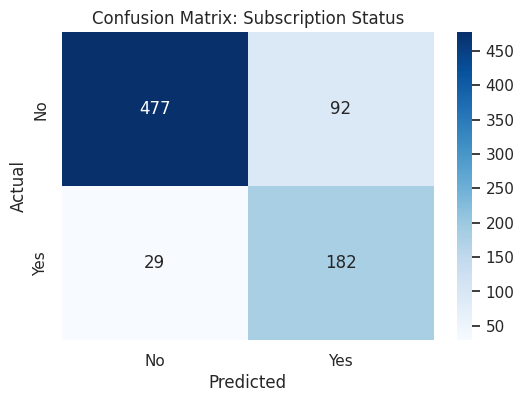

In [10]:
# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix: Subscription Status')
plt.show()